In [67]:
from google.colab import files
uploaded = files.upload()

Saving ad_viz_plotval_data (4).csv to ad_viz_plotval_data (4).csv
Saving ad_viz_plotval_data (3).csv to ad_viz_plotval_data (3).csv


In [68]:
import pandas as pd

df_2022 = pd.read_csv("ad_viz_plotval_data (3).csv")
df_2023 = pd.read_csv("ad_viz_plotval_data (4).csv")


In [69]:
df = pd.concat([df_2022, df_2023], ignore_index=True)


In [71]:
import pandas as pd

df_2022 = pd.read_csv("ad_viz_plotval_data (3).csv")
df_2023 = pd.read_csv("ad_viz_plotval_data (4).csv")

print(df_2022.columns)
print(df_2023.columns)


Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM10 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')
Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Mean PM10 Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


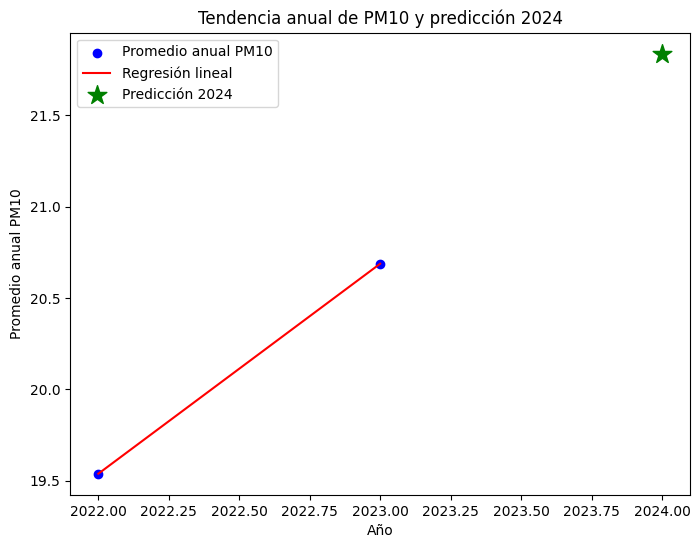

Predicción anual PM10 para 2024: 21.83649104902861


/tmp/ipykernel_3551/2553669888.py:61: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas_2024 = pd.date_range("2024-01-01", periods=12, freq="M")


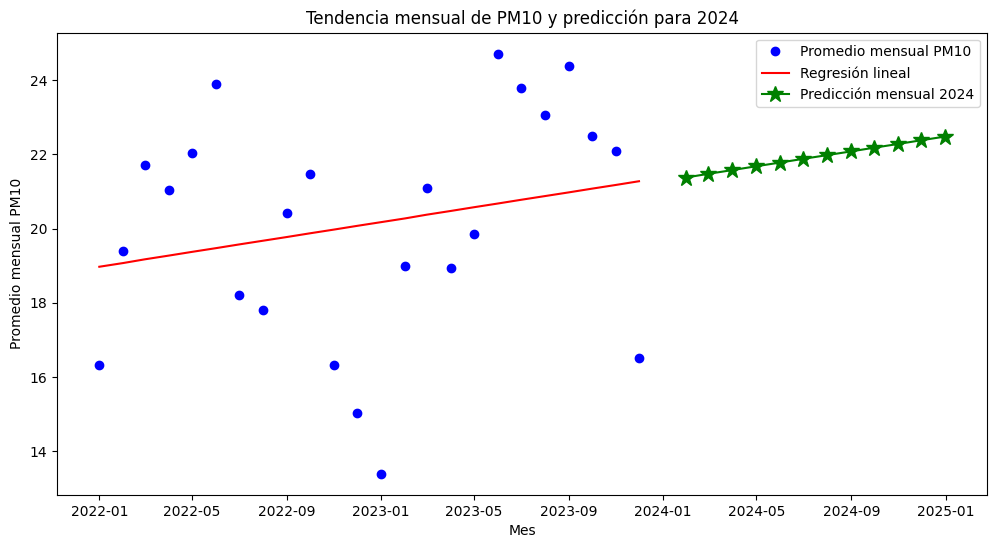

        Mes  Predicción PM10
0   2024-01        21.379017
1   2024-02        21.479257
2   2024-03        21.579498
3   2024-04        21.679738
4   2024-05        21.779978
5   2024-06        21.880218
6   2024-07        21.980459
7   2024-08        22.080699
8   2024-09        22.180939
9   2024-10        22.281180
10  2024-11        22.381420
11  2024-12        22.481660


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Leer y unir datos
df_2022 = pd.read_csv("ad_viz_plotval_data (3).csv")
df_2023 = pd.read_csv("ad_viz_plotval_data (4).csv")
df = pd.concat([df_2022, df_2023], ignore_index=True)

# 2. Convertir fechas
df["Date"] = pd.to_datetime(df["Date"])

# =========================
# 📊 Gráfico ANUAL
# =========================
# Agrupar por año
df_anual = df.groupby(df["Date"].dt.year)["Daily Mean PM10 Concentration"].mean().reset_index()

# Variables para regresión
X_anual = df_anual[["Date"]]  # años
y_anual = df_anual["Daily Mean PM10 Concentration"]

# Ajustar modelo
modelo_anual = LinearRegression()
modelo_anual.fit(X_anual, y_anual)

# Predicción para 2024
pred_2024_anual = modelo_anual.predict([[2024]])

# Gráfico anual
plt.figure(figsize=(8,6))
plt.scatter(X_anual, y_anual, color="blue", label="Promedio anual PM10")
plt.plot(X_anual, modelo_anual.predict(X_anual), color="red", label="Regresión lineal")
plt.scatter([2024], pred_2024_anual, color="green", s=200, marker="*", label="Predicción 2024")
plt.legend()
plt.xlabel("Año")
plt.ylabel("Promedio anual PM10")
plt.title("Tendencia anual de PM10 y predicción 2024")
plt.show()

print("Predicción anual PM10 para 2024:", pred_2024_anual[0])

# =========================
# 📊 Gráfico MENSUAL
# =========================
# Agrupar por mes
df_mensual = df.groupby(df["Date"].dt.to_period("M"))["Daily Mean PM10 Concentration"].mean().reset_index()
df_mensual["Date"] = df_mensual["Date"].dt.to_timestamp()

# Variables para regresión
X_mensual = df_mensual.index.values.reshape(-1,1)   # índice de meses
y_mensual = df_mensual["Daily Mean PM10 Concentration"]

# Ajustar modelo
modelo_mensual = LinearRegression()
modelo_mensual.fit(X_mensual, y_mensual)

# Predicción para los 12 meses de 2024
n_meses = len(df_mensual)
pred_2024_mensual = modelo_mensual.predict([[n_meses+i] for i in range(12)])
fechas_2024 = pd.date_range("2024-01-01", periods=12, freq="M")

# Gráfico mensual
plt.figure(figsize=(12,6))
plt.plot(df_mensual["Date"], y_mensual, "o", color="blue", label="Promedio mensual PM10")
plt.plot(df_mensual["Date"], modelo_mensual.predict(X_mensual), color="red", label="Regresión lineal")
plt.plot(fechas_2024, pred_2024_mensual, "g*-", markersize=12, label="Predicción mensual 2024")
plt.legend()
plt.xlabel("Mes")
plt.ylabel("Promedio mensual PM10")
plt.title("Tendencia mensual de PM10 y predicción para 2024")
plt.show()

# Mostrar tabla de predicciones mensuales
pred_df = pd.DataFrame({"Mes": fechas_2024.strftime("%Y-%m"), "Predicción PM10": pred_2024_mensual})
print(pred_df)



In [82]:
from sklearn.metrics import r2_score

# Para el gráfico anual
r2_anual = r2_score(y_anual, modelo_anual.predict(X_anual))
print("R² anual:", r2_anual)

# Para el gráfico mensual
r2_mensual = r2_score(y_mensual, modelo_mensual.predict(X_mensual))
print("R² mensual:", r2_mensual)


R² anual: 1.0
R² mensual: 0.05239108494217071


R² anual: 1.0


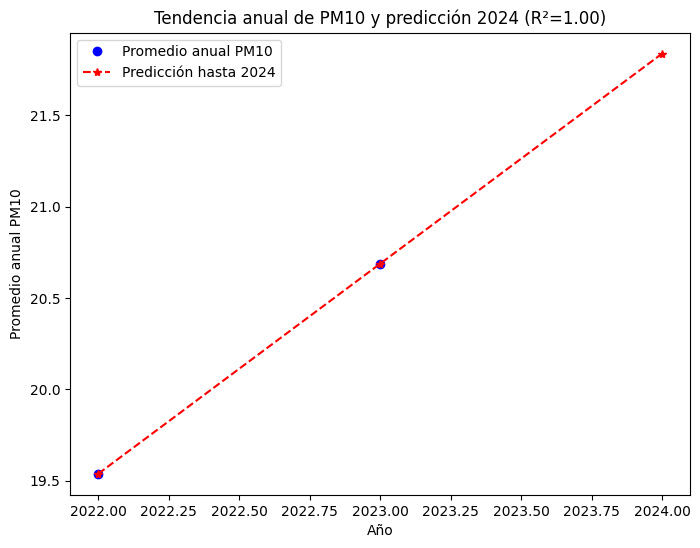

R² mensual: 0.05239108494217071


/tmp/ipykernel_3551/2264748386.py:54: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas_2024 = pd.date_range("2024-01-01", periods=12, freq="M")


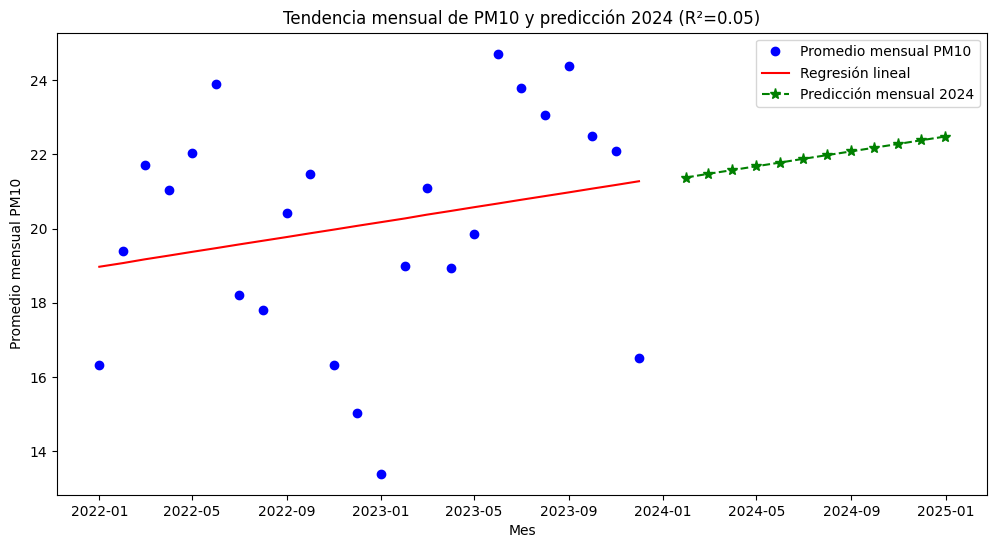

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Leer y unir datos
df_2022 = pd.read_csv("ad_viz_plotval_data (3).csv")
df_2023 = pd.read_csv("ad_viz_plotval_data (4).csv")
df = pd.concat([df_2022, df_2023], ignore_index=True)

df["Date"] = pd.to_datetime(df["Date"])

# =========================
# 📊 Gráfico ANUAL
# =========================
df_anual = df.groupby(df["Date"].dt.year)["Daily Mean PM10 Concentration"].mean().reset_index()

X_anual = df_anual[["Date"]]  # años
y_anual = df_anual["Daily Mean PM10 Concentration"]

modelo_anual = LinearRegression()
modelo_anual.fit(X_anual, y_anual)

años_ext = pd.DataFrame({"Date":[2022,2023,2024]})
pred_anual = modelo_anual.predict(años_ext)

# Calcular R² anual
r2_anual = r2_score(y_anual, modelo_anual.predict(X_anual))
print("R² anual:", r2_anual)

plt.figure(figsize=(8,6))
plt.plot(df_anual["Date"], y_anual, "o", color="blue", label="Promedio anual PM10")
plt.plot(años_ext["Date"], pred_anual, color="red", linestyle="--", marker="*", label="Predicción hasta 2024")
plt.legend()
plt.xlabel("Año")
plt.ylabel("Promedio anual PM10")
plt.title(f"Tendencia anual de PM10 y predicción 2024 (R²={r2_anual:.2f})")
plt.show()

# =========================
# 📊 Gráfico MENSUAL
# =========================
df_mensual = df.groupby(df["Date"].dt.to_period("M"))["Daily Mean PM10 Concentration"].mean().reset_index()
df_mensual["Date"] = df_mensual["Date"].dt.to_timestamp()

X_mensual = df_mensual.index.values.reshape(-1,1)
y_mensual = df_mensual["Daily Mean PM10 Concentration"]

modelo_mensual = LinearRegression()
modelo_mensual.fit(X_mensual, y_mensual)

n_meses = len(df_mensual)
pred_2024_mensual = modelo_mensual.predict([[n_meses+i] for i in range(12)])
fechas_2024 = pd.date_range("2024-01-01", periods=12, freq="M")

# Calcular R² mensual
r2_mensual = r2_score(y_mensual, modelo_mensual.predict(X_mensual))
print("R² mensual:", r2_mensual)

plt.figure(figsize=(12,6))
plt.plot(df_mensual["Date"], y_mensual, "o", color="blue", label="Promedio mensual PM10")
plt.plot(df_mensual["Date"], modelo_mensual.predict(X_mensual), color="red", label="Regresión lineal")
plt.plot(fechas_2024, pred_2024_mensual, "g--*", markersize=8, label="Predicción mensual 2024")
plt.legend()
plt.xlabel("Mes")
plt.ylabel("Promedio mensual PM10")
plt.title(f"Tendencia mensual de PM10 y predicción 2024 (R²={r2_mensual:.2f})")
plt.show()
